In [30]:
####### COMPILE ALL GRAPHS #######
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
import sys;sys.path.append("../gnn");sys.path.append("../networks")
from utils import resolve_paths, load_atlas_data
from gnnutils import *

READ_DATA_PATHS, WRITE_DATA_PATHS = resolve_paths(read_datasets=["Atlas Trade Data",
                                                                "Atlas Countries Data", 
                                                                "Atlas Products Data",
                                                                "BACI Data",
                                                                 "Graphs Data",
                                                                 "Results Data"], 
                                                write_datasets=["Graphs Data"])

Loading DATA_PATHS.yaml from ../../data/DATA_PATHS.yaml


## Settings

In [3]:
digits = 2 # 2 or 4
transaction = "export" # "imports" or "total"

#### Load data

In [4]:
# Read imports volume data
df = load_atlas_data(READ_DATA_PATHS["Atlas Trade Data"])
atlas = df.drop(columns=["coi", "eci", "pci"])

# Read Atlas product ID to commodity mapping
products = pd.read_csv(READ_DATA_PATHS["Atlas Products Data"], 
                       dtype={"code": str})
countries = pd.read_csv(READ_DATA_PATHS["Atlas Countries Data"], 
                        encoding="latin-1")
products = products[["product_id", "code", "name_short_en"]]
products["code"] = products["code"].str[:digits]
    
# # Get commodity from mapping
atlas = atlas.merge(products, on="product_id", how="left", indicator=False)
atlas = atlas[~(atlas["code"].str.startswith("XX") & ~atlas["code"].str.startswith("99"))]

atlas.head()

,country_id,partner_country_id,year,product_id,export_value,import_value,code,name_short_en
0,4,12,2014,716,24283.0,0.0,08,Grapes
1,4,36,2014,716,1080066.0,0.0,08,Grapes
2,4,48,2014,716,16698.0,0.0,08,Grapes
3,4,56,2014,716,77203.0,0.0,08,Grapes
4,4,76,2014,716,668840.0,0.0,08,Grapes


### Case settings

Choose:
- GNN Model
- Graph (export, total)
- Number of main exports
- Base year: the year of comparison

In [5]:
model = "GAT"  # Choose model: MLP, GCN, SAGE or GAT
graph = "export"
n_main_exports = 5
dependency_threshold = 0.5
base_year = 2021
digits = 2

Check what country ID corresponds to Russia

In [6]:
russia_id = countries[countries.country == "Russian Federation"].country_id.values[0]
ukraine_id = countries[countries.country == "Ukraine"].country_id.values[0]

Look who are russian importers at base year

In [ ]:
# All imports per country in base_year
all_imports = atlas.loc[(atlas.import_value > 0) & (atlas.year == base_year), ["country_id", "code", "import_value"]]\
    .groupby(["country_id", "code"]).sum().reset_index()

# All imports from Russia in base_year
imports_from_russia = atlas.loc[(atlas.partner_country_id == russia_id) &
                                 (atlas.import_value > 0) & (atlas.year == base_year), ["country_id", "code", "import_value"]]\
    .groupby(["country_id", "code"]).sum().reset_index()

# All imports from Ukraine in base_year
imports_from_ukraine = atlas.loc[(atlas.partner_country_id == ukraine_id) &
                                (atlas.import_value > 0) & (atlas.year == base_year), ["country_id", "code", "import_value"]]\
    .groupby(["country_id", "code"]).sum().reset_index()

Calculate the dependency ratio of each country

In [8]:
russian_dependency = all_imports.merge(imports_from_russia, on=["country_id", "code"], how="left", suffixes=("_total", "_from_russia"))
russian_dependency["dependency_ratio"] = russian_dependency["import_value_from_russia"] / russian_dependency["import_value_total"]
russian_dependency["dependency_ratio"] = russian_dependency["dependency_ratio"].fillna(0)
russian_dependency.head()

ukraine_dependency = all_imports.merge(imports_from_ukraine, on=["country_id", "code"], how="left", suffixes=("_total", "_from_ukraine"))
ukraine_dependency["dependency_ratio"] = ukraine_dependency["import_value_from_ukraine"] / ukraine_dependency["import_value_total"]
ukraine_dependency["dependency_ratio"] = ukraine_dependency["dependency_ratio"].fillna(0)
ukraine_dependency.head()

,country_id,code,import_value_total,import_value_from_ukraine,dependency_ratio
0,4,01,6359961.0,NaN,0.000000
1,4,02,61496362.0,62859.0,0.001022
2,4,03,2274524.0,NaN,0.000000
3,4,04,96253601.0,NaN,0.000000
4,4,05,195442.0,NaN,0.000000


Add risk

In [9]:
risk = pd.read_csv(READ_DATA_PATHS["Results Data"] +
                    f"/Risk Scores/{digits}_digits/{model}-{graph}-risk-scores.csv", 
                    dtype={"commodity": str}).rename(columns={"commodity": "code"})

In [10]:
risk.head()

,year,model_type,graph_type,code,y,preds,probs,country_id,import_value,risk_score
0,2012,GAT,export,01,0,0,1.580000e-07,533,4950261.0,0.784239
1,2012,GAT,export,01,0,0,3.740000e-08,4,10045869.0,0.375509
2,2012,GAT,export,01,0,0,9.980000e-07,24,15581754.0,15.551687
3,2012,GAT,export,01,0,0,6.990000e-08,8,26669729.0,1.865125
4,2012,GAT,export,01,0,0,4.210000e-09,20,167561.0,0.000706


In [11]:
russian_dependency = russian_dependency.merge(risk.loc[risk.year == base_year, ["country_id", "code", "probs"]],\
                                               on=["country_id", "code"], suffixes=["", "_risk"], how="left") \
 .merge(risk.loc[risk.year == base_year+1, ["country_id", "code", "probs"]], on=["country_id", "code"], suffixes=["", f"_{base_year+1}"], how="left")

ukraine_dependency = ukraine_dependency.merge(risk.loc[risk.year == base_year, ["country_id", "code", "probs"]],\
                                               on=["country_id", "code"], suffixes=["", "_risk"], how="left") \
 .merge(risk.loc[risk.year == base_year+1, ["country_id", "code", "probs"]], on=["country_id", "code"], suffixes=["", f"_{base_year+1}"], how="left")

In [12]:
russian_dependency.head()

,country_id,code,import_value_total,import_value_from_russia,dependency_ratio,probs,probs_2022
0,4,01,6359961.0,NaN,0.000000,2.360000e-06,1.740000e-06
1,4,02,61496362.0,NaN,0.000000,1.034421e-03,4.450000e-07
2,4,03,2274524.0,NaN,0.000000,2.077880e-04,5.149534e-01
3,4,04,96253601.0,332708.0,0.003457,9.945328e-01,9.928219e-01
4,4,05,195442.0,NaN,0.000000,9.010000e-11,3.350000e-10


Test differences

# Main Exports from Russia & Ukraine

In [13]:
with open(READ_DATA_PATHS["Graphs Data"] + f"/{digits}_digits/SRCA.pickle", "rb") as f:
    rca_dict = pickle.load(f)

# Product 99 is undefined
rca_dict[base_year] = rca_dict[base_year].drop("XX", axis=1)
rca_dict[base_year] = rca_dict[base_year].drop("99", axis=1)

In [14]:
main_prods_russia = pd.DataFrame(rca_dict[base_year].loc[russia_id][rca_dict[base_year].loc[russia_id] > 1].sort_values(ascending=False)[:n_main_exports])
main_prods_ukraine = pd.DataFrame(rca_dict[base_year].loc[ukraine_id][rca_dict[base_year].loc[ukraine_id] > 1].sort_values(ascending=False)[:n_main_exports])

In [15]:
#main_prods = main_prods.drop("99")
main_prods_russia

,643
31,6.364379
75,5.412801
27,3.695990
10,3.240061
44,2.989491


In [16]:
main_prods_russia_ids = main_prods_russia.index.astype(str).str.zfill(digits).tolist()
main_prods_ukraine_ids = main_prods_ukraine.index.astype(str).str.zfill(digits).tolist()

In [17]:
russian_dependency_main_prods = russian_dependency[russian_dependency.code.isin(main_prods_russia_ids)]
ukraine_dependency_main_prods = ukraine_dependency[ukraine_dependency.code.isin(main_prods_ukraine_ids)]

In [18]:
ukraine_dependency_main_prods

,country_id,code,import_value_total,import_value_from_ukraine,dependency_ratio,probs,probs_2022
9,4,10,275059051.0,NaN,0.000000,0.926774,6.636345e-02
13,4,14,1289123.0,NaN,0.000000,0.000633,1.090000e-07
14,4,15,404377926.0,56883.0,0.000141,0.000013,7.680000e-08
22,4,23,26403319.0,NaN,0.000000,0.037729,2.661090e-04
70,4,72,180655251.0,NaN,0.000000,0.008525,2.429384e-01
...,...,...,...,...,...,...,...
21368,999,10,341397989.0,NaN,0.000000,0.410286,2.766504e-01
21372,999,14,278573.0,NaN,0.000000,0.621615,1.710117e-02
21373,999,15,488893434.0,3412.0,0.000007,0.101684,3.050652e-02
21381,999,23,108607441.0,NaN,0.000000,0.116496,4.894516e-01


In [19]:
#russian_dependency_main_prods_year = russian_dependency_main_prods.groupby("country_id").max().reset_index()
russian_dependency_main_prods["difference_risk"] = russian_dependency_main_prods[f"probs_{base_year+1}"] - russian_dependency_main_prods["probs"]
high_russian_dependency_main_prods = russian_dependency_main_prods[russian_dependency_main_prods.dependency_ratio >= dependency_threshold]
low_russian_dependency_main_prods = russian_dependency_main_prods[russian_dependency_main_prods.dependency_ratio < dependency_threshold]

ukraine_dependency_main_prods["difference_risk"] = ukraine_dependency_main_prods[f"probs_{base_year+1}"] - ukraine_dependency_main_prods["probs"]
high_ukraine_dependency_main_prods = ukraine_dependency_main_prods[ukraine_dependency_main_prods.dependency_ratio >= dependency_threshold]
low_ukraine_dependency_main_prods = ukraine_dependency_main_prods[ukraine_dependency_main_prods.dependency_ratio < dependency_threshold]

C:\Users\ginof\AppData\Local\Temp\ipykernel_18336\191064153.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  russian_dependency_main_prods["difference_risk"] = russian_dependency_main_prods[f"probs_{base_year+1}"] - russian_dependency_main_prods["probs"]
C:\Users\ginof\AppData\Local\Temp\ipykernel_18336\191064153.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ukraine_dependency_main_prods["difference_risk"] = ukraine_dependency_main_prods[f"probs_{base_year+1}"] - ukraine_dependency_main_prods["prob

In [20]:
print(high_russian_dependency_main_prods.shape[0], low_russian_dependency_main_prods.shape[0])
print()
print(high_ukraine_dependency_main_prods.shape[0], low_ukraine_dependency_main_prods.shape[0])

32 1071

3 1101


In [21]:
low_russian_dependency_main_prods = low_russian_dependency_main_prods.dropna(subset=["difference_risk"])
low_ukraine_dependency_main_prods = low_ukraine_dependency_main_prods.dropna(subset=["difference_risk"])

In [22]:
print(f"Russia: Low Dependency Mean Risk: {low_russian_dependency_main_prods.difference_risk.mean()} | High Dpeendency Mean Risk: {high_russian_dependency_main_prods.difference_risk.mean()}")
print(f"Ukraine: Low Dependency Mean Risk: {low_ukraine_dependency_main_prods.difference_risk.mean()} | High Dpeendency Mean Risk: {high_ukraine_dependency_main_prods.difference_risk.mean()}")

Russia: Low Dependency Mean Risk: 0.016275649133903773 | High Dpeendency Mean Risk: 0.08443616616246931
Ukraine: Low Dependency Mean Risk: 0.005870361371999843 | High Dpeendency Mean Risk: -0.08844199523333329


In [24]:
from scipy.stats import mannwhitneyu

u_russia, p_russia = mannwhitneyu(low_russian_dependency_main_prods.difference_risk, high_russian_dependency_main_prods.difference_risk)
u_ukraine, p_ukraine = mannwhitneyu(low_ukraine_dependency_main_prods.difference_risk, high_ukraine_dependency_main_prods.difference_risk)

print(f"p-value Russia = {p_russia:.4f}")
print(f"p-value Ukraine = {p_ukraine:.4f}")

p-value Russia = 0.0423
p-value Ukraine = 0.9897


''

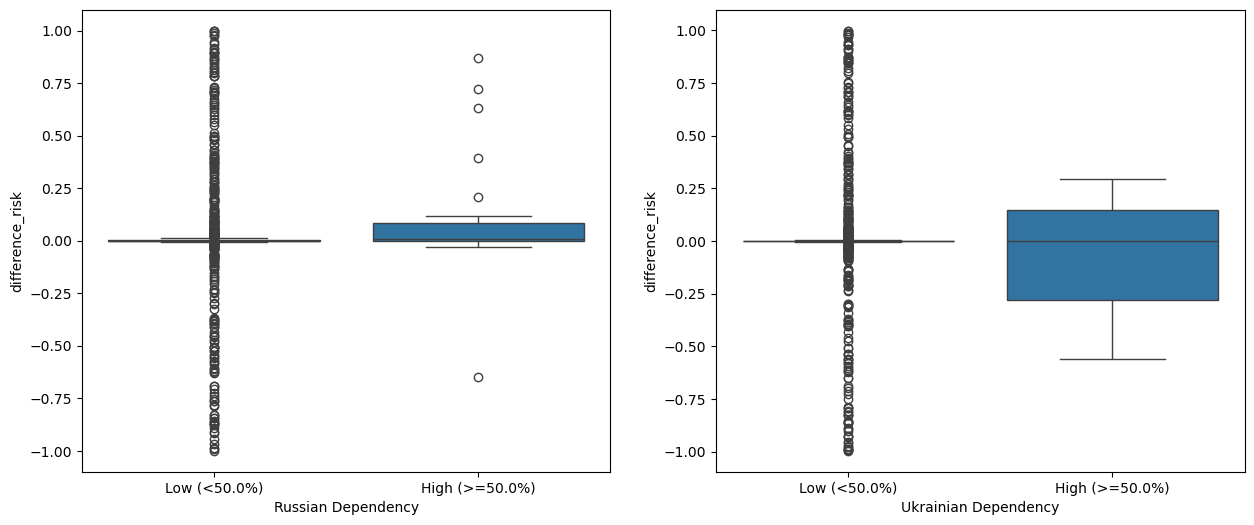

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.mode.copy_on_write = True

low_russian_dependency_main_prods.loc[:,"Russian Dependency"] = f"Low (<{dependency_threshold*100}%)"
high_russian_dependency_main_prods.loc[:,"Russian Dependency"] = f"High (>={dependency_threshold*100}%)"

low_ukraine_dependency_main_prods.loc[:,"Ukrainian Dependency"] = f"Low (<{dependency_threshold*100}%)"
high_ukraine_dependency_main_prods.loc[:,"Ukrainian Dependency"] = f"High (>={dependency_threshold*100}%)"

fig, ax = plt.subplots(1,2, figsize=(15,6))

boxplot_data_russia = pd.concat([low_russian_dependency_main_prods[["difference_risk", "Russian Dependency"]],
                         high_russian_dependency_main_prods[["difference_risk", "Russian Dependency"]]])

boxplot_data_ukraine = pd.concat([low_ukraine_dependency_main_prods[["difference_risk", "Ukrainian Dependency"]],
                         high_ukraine_dependency_main_prods[["difference_risk", "Ukrainian Dependency"]]])


sns.boxplot(data=boxplot_data_russia, x="Russian Dependency", y="difference_risk", ax=ax[0])
sns.boxplot(data=boxplot_data_ukraine, x="Ukrainian Dependency", y="difference_risk", ax=ax[1])
;

In-depth

In [35]:
prices_base_year = pd.read_csv(READ_DATA_PATHS["BACI Data"] + f"/BACI_HS12_Y{base_year}_V202501.csv", \
                               dtype={"product_id": str})
prices_base_year["code"] = prices_base_year["product_id"].str[:digits]
prices_base_year = prices_base_year[["importer", "code", "export_value", "qty"]].groupby(["importer", "code"]).sum().reset_index()
prices_base_year["avg_price"] = prices_base_year["export_value"] / prices_base_year["qty"]
prices_next_year = pd.read_csv(READ_DATA_PATHS["BACI Data"] + f"/BACI_HS12_Y{base_year+1}_V202501.csv", \
                               dtype={"product_id": str})
prices_next_year["code"] = prices_next_year["product_id"].str[:digits]
prices_next_year = prices_next_year[["importer", "code", "export_value", "qty"]].groupby(["importer", "code"]).sum().reset_index()
prices_next_year["avg_price"] = prices_next_year["export_value"] / prices_next_year["qty"]

In [36]:
prices_next_year

,importer,code,export_value,qty,avg_price
0,4,01,6076.488,7488.536,0.811439
1,4,02,85109.345,49903.091,1.705492
2,4,03,3295.262,846.245,3.893981
3,4,04,171899.643,103576.730,1.659636
4,4,05,160.197,57.997,2.762160
...,...,...,...,...,...
21046,894,93,1683.063,76.412,22.026161
21047,894,94,81633.464,16544.849,4.934071
21048,894,95,6861.274,648.334,10.582931
21049,894,96,27978.280,6814.988,4.105404


In [37]:
len(high_russian_dependency_main_prods)

32

In [38]:
high_russian_dependency_main_prods

,country_id,code,import_value_total,import_value_from_russia,dependency_ratio,probs,probs_2022,difference_risk,Russian Dependency
721,31,10,3.324780e+08,2.966774e+08,0.892322,1.541441e-02,1.342980e-01,1.188836e-01,High (>=50.0%)
742,31,31,4.739362e+07,3.315295e+07,0.699524,4.058192e-03,4.788227e-03,7.300350e-04,High (>=50.0%)
755,31,44,3.280089e+08,2.454286e+08,0.748238,2.872386e-03,2.108425e-01,2.079701e-01,High (>=50.0%)
1400,51,10,5.340260e+07,5.139284e+07,0.962366,5.038650e-04,7.773654e-02,7.723268e-02,High (>=50.0%)
1417,51,27,6.540102e+08,4.963688e+08,0.758962,3.240000e-05,8.484694e-03,8.452294e-03,High (>=50.0%)
2995,112,10,1.369985e+08,8.176444e+07,0.596827,3.040000e-05,5.760000e-06,-2.464000e-05,High (>=50.0%)
3012,112,27,6.546504e+09,6.320584e+09,0.965490,9.400000e-05,2.510574e-03,2.416574e-03,High (>=50.0%)
3016,112,31,1.748108e+08,1.670207e+08,0.955437,9.820000e-13,6.110000e-07,6.109990e-07,High (>=50.0%)
3029,112,44,2.231100e+08,1.532916e+08,0.687067,6.850000e-05,2.420000e-08,-6.847580e-05,High (>=50.0%)
3060,112,75,9.082540e+06,5.533211e+06,0.609214,5.720000e-05,6.990000e-07,-5.650100e-05,High (>=50.0%)


In [41]:
for ix, row in high_russian_dependency_main_prods.iterrows():
    code = row["code"]
    country_id = row["country_id"]
    country_name = countries[countries.country_id == country_id].country.values[0]
    if country_id == 756: country_id = 757  # Adjust for Switzerland
    prod_name = products[products.code == code].name_short_en.values[0]
    print(f"Country: {country_name} ({country_id}) | Product: {prod_name} ({code}) | Dependency: {row['dependency_ratio']:.2f} | Risk Increase: {row['difference_risk']:.4f}")
    # Next year
    next_year = atlas.loc[(atlas.country_id == country_id) & (atlas.code == code) & (atlas.year == base_year+1)]
    avg_price_base_year = prices_base_year.loc[(prices_base_year.importer == country_id) 
                                               & (prices_base_year.code == code), 'avg_price'].values[0]
    avg_price_next_year = prices_next_year.loc[(prices_next_year.importer == country_id) 
                                               & (prices_next_year.code == code), 'avg_price'].values[0]
    if not next_year.empty:
        import_value_next_year = next_year.import_value.sum()
        import_value_russia_next_year = next_year.loc[next_year.partner_country_id == russia_id].import_value.sum()
        print(f"Import Value {base_year}: {row['import_value_total']:,} | Import Value {base_year+1}: {import_value_next_year:,} ({(import_value_next_year/row['import_value_total'])-1:.2%})")
        print(f"Avg. Price {base_year}: {avg_price_base_year:.2f} | Next year: {avg_price_next_year:.2f}")
        print(f" * From  Russia: {base_year}: {row['import_value_from_russia']:,} | {base_year+1}: {import_value_russia_next_year:,} ({(import_value_russia_next_year/row['import_value_from_russia'])-1:.2%})")
    print("-----")

Country: Azerbaijan (31) | Product: Other (10) | Dependency: 0.89 | Risk Increase: 0.1189
Import Value 2013: 332,477,992.0 | Import Value 2014: 430,074,631.0 (29.35%)
Avg. Price 2013: 0.29 | Next year: 0.31
 * From  Russia: 2013: 296,677,411.0 | 2014: 265,743,300.0 (-10.43%)
-----
Country: Azerbaijan (31) | Product: Fertilisers (31) | Dependency: 0.70 | Risk Increase: 0.0007
Import Value 2013: 47,393,618.0 | Import Value 2014: 52,725,158.0 (11.25%)
Avg. Price 2013: 0.46 | Next year: 0.41
 * From  Russia: 2013: 33,152,954.0 | 2014: 36,606,433.0 (10.42%)
-----
Country: Azerbaijan (31) | Product: Wood (44) | Dependency: 0.75 | Risk Increase: 0.2080
Import Value 2013: 328,008,871.0 | Import Value 2014: 452,018,872.0 (37.81%)
Avg. Price 2013: 0.46 | Next year: 0.52
 * From  Russia: 2013: 245,428,574.0 | 2014: 259,099,186.0 (5.57%)
-----
Country: Armenia (51) | Product: Other (10) | Dependency: 0.96 | Risk Increase: 0.0772
Import Value 2013: 53,402,603.0 | Import Value 2014: 67,452,426.0 (26

# New Approach
So I'm thinking of a different plot. First, you select all countries that import a lot (threshold of your choice) of a product p from Russia (and/or Ukraine). Then you divide them into two groups: the first got a low risk score from GAT-total in 2021 (and/or 2013), the other got a high score. On the y-axis you can then report the % of those countries who were actually affected (according to our definition of being affected) in 2022 (and/or 2014, thank god Russia always invades at the beginning of the calendar year).

Ideally the bar with high risk scores should be higher than the one with low risk scores.

In [42]:
atlas_data = atlas.groupby(["year", "country_id", "partner_country_id", "code"]).sum().reset_index()

In [63]:
base_year = 2021

high_scra = rca_dict[base_year].loc[russia_id][rca_dict[base_year].loc[russia_id] > 1]
if "XX" in high_scra.index:
    high_scra = high_scra.drop("XX")
if "99" in high_scra.index:
    high_scra = high_scra.drop("99")
pd.DataFrame(high_scra.sort_values(ascending=False)[:10]).reset_index()

,index,643
0,31,6.364379
1,75,5.412801
2,27,3.695990
3,10,3.240061
4,44,2.989491
5,72,2.346232
6,03,2.146611
7,81,1.884448
8,15,1.707730
9,71,1.671178


Select a product

In [89]:
code = "31"

print(code, products[products.code == code].name_short_en.values[0])

31 Fertilisers


Look at the median and mean export

In [90]:
export_median = atlas_data.loc[(atlas_data.country_id == russia_id) & 
                               (atlas_data.code == code) & (atlas_data.year == base_year) & 
                               (atlas_data.export_value > 0)].export_value.median()

export_mean = atlas_data.loc[(atlas_data.country_id == russia_id) & 
                              (atlas_data.code == code) & (atlas_data.year == base_year) & 
                              (atlas_data.export_value > 0)].export_value.mean()

print(f"Median export value of product {code} from Russia in {base_year}: {export_median:,.2f}")
print(f"Mean export value of product {code} from Russia in {base_year}: {export_mean:,.2f}")

Median export value of product 31 from Russia in 2021: 10,705,833.00
Mean export value of product 31 from Russia in 2021: 86,691,941.40


Select either median or mean as the threshold to consider an "important" importer of X product

In [91]:
method = "median"  # "median" or "mean"
threshold = export_median if method == "median" else export_mean

high_importers_of_x_prod = atlas_data.loc[(atlas_data.country_id == russia_id) & 
                                          (atlas_data.code == code) & (atlas_data.year == base_year) & 
                                          (atlas_data.export_value > threshold)].sort_values(by="export_value", ascending=False)

In [ ]:
print(f"Number of importers of product {code} from Russia in {base_year}: {len(atlas_data.loc[(atlas_data.country_id == russia_id) & 
                         (atlas_data.code == code) & (atlas_data.year == base_year) & 
                         (atlas_data.export_value > 0)])}")
print(f"Number of high importers of product {code} from Russia in {base_year}: {len(high_importers_of_x_prod)}")

139
69


In [77]:
high_importers_of_nickel.head(2)

,year,country_id,partner_country_id,code,product_id,export_value,import_value,name_short_en
9973768,2021,643,246,75,10732,1.035879e+09,379647.0,"Other articles of nickelNickel bars, wire etc...."
9972697,2021,643,156,75,10736,8.691161e+08,15217031.0,Nickel tubes and pipesOther articles of nickel...


In [78]:
risk.head(2)

,year,model_type,graph_type,code,y,preds,probs,country_id,import_value,risk_score
0,2012,GAT,export,01,0,0,1.580000e-07,533,4950261.0,0.784239
1,2012,GAT,export,01,0,0,3.740000e-08,4,10045869.0,0.375509


In [79]:
high_importers_of_nickel = high_importers_of_nickel.merge(risk, left_on=["year", "code", "partner_country_id"], right_on=["year", "code", "country_id"])

In [80]:
high_importers_of_nickel_high_risk = high_importers_of_nickel[high_importers_of_nickel.probs >= 0.5]
high_importers_of_nickel_low_risk = high_importers_of_nickel[high_importers_of_nickel.probs < 0.5]

In [87]:
print(f"High Risk: {len(high_importers_of_nickel_high_risk)}")
print(f"Low Risk: {len(high_importers_of_nickel_low_risk)}")

High Risk: 9
Low Risk: 28


In [88]:
print(len(high_importers_of_nickel_high_risk[high_importers_of_nickel_high_risk.y == 1]), high_importers_of_nickel_high_risk.y.mean())
print(len(high_importers_of_nickel_low_risk[high_importers_of_nickel_low_risk.y == 1]), high_importers_of_nickel_low_risk.y.mean())

4 0.4444444444444444
8 0.2857142857142857


In [83]:
high_importers_of_nickel_high_risk

,year,country_id_x,partner_country_id,code,product_id,export_value,import_value_x,name_short_en,model_type,graph_type,y,preds,probs,country_id_y,import_value_y,risk_score
1,2021,643,156,75,10736,869116134.0,15217031.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,0,1,0.905449,156,8.570624e+09,7.760266e+09
2,2021,643,528,75,10738,438240144.0,512853.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,0,1,0.999992,528,1.405193e+09,1.405182e+09
4,2021,643,702,75,6138,121201458.0,25383.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,1,1,0.999971,702,4.296888e+08,4.296763e+08
5,2021,643,784,75,7673,103776427.0,1129338.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,1,1,0.995394,784,3.551637e+08,3.535279e+08
6,2021,643,616,75,10738,62834126.0,2029601.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,0,1,0.728525,616,1.945642e+08,1.417450e+08
8,2021,643,356,75,9206,48196820.0,166598.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,0,1,0.993117,356,2.424729e+09,2.408039e+09
20,2021,643,724,75,7671,5449380.0,303208.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,1,1,0.853996,724,3.220215e+08,2.750052e+08
23,2021,643,752,75,9207,2519728.0,194706.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,1,1,0.588109,752,4.741288e+08,2.788394e+08
33,2021,643,36,75,6140,538357.0,22414.0,Nickel tubes and pipesOther articles of nickel...,GAT,export,0,1,0.999972,36,9.910911e+07,9.910636e+07
